# 🍅 VMF-SSD: Tomato Leaf Disease Detection
### V-Space Multi-Scale Feature Fusion SSD for Tomato Disease Detection
---
**Based on:** IEEE/ACM Transactions on Computational Biology and Bioinformatics, 2023

**Architecture Components:**
- Multi-Scale Feature Extraction Block
- V-Space Based Location Branch (HSV color space)
- Multi-Scale Attention Mechanism
- VGGNet-16 Backbone with SSD Detection Head

 ✅ Step 1: Mount Google Drive







In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


✅ Step 2: Install Dependencies

In [2]:
!pip install opencv-python-headless albumentations --quiet
print('✅ Dependencies installed!')

✅ Dependencies installed!


Step 3: Imports & Configuration

In [4]:
import os, cv2, random, time, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# ── Config ─────────────────────────────────────────────────
DRIVE_BASE   = '/content/drive/MyDrive/tomato_project'
DATASET_DIR  = os.path.join(DRIVE_BASE, 'dataset')
MODEL_SAVE   = os.path.join(DRIVE_BASE, 'vmf_ssd_tomato.pth')

IMG_SIZE     = 512
BATCH_SIZE   = 8
NUM_EPOCHS   = 25
LEARNING_RATE = 0.001
SPLIT_RATIO  = 0.8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


Step 4: Dataset Preparation

In [5]:
# ── Get all classes ────────────────────────────────────────
classes = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
NUM_CLASSES = len(classes)

print(f'Found {NUM_CLASSES} disease classes:')
for idx, cls in enumerate(classes):
    count = len(os.listdir(os.path.join(DATASET_DIR, cls)))
    print(f'  [{idx}] {cls} — {count} images')

Found 10 disease classes:
  [0] Tomato___Bacterial_spot — 108 images
  [1] Tomato___Early_blight — 298 images
  [2] Tomato___Late_blight — 111 images
  [3] Tomato___Leaf_Mold — 405 images
  [4] Tomato___Septoria_leaf_spot — 106 images
  [5] Tomato___Spider_mites Two-spotted_spider_mite — 121 images
  [6] Tomato___Target_Spot — 117 images
  [7] Tomato___Tomato_Yellow_Leaf_Curl_Virus — 100 images
  [8] Tomato___Tomato_mosaic_virus — 109 images
  [9] Tomato___healthy — 157 images


In [6]:
# ── Collect all image paths with labels ───────────────────
all_data = []
for cls in classes:
    cls_dir = os.path.join(DATASET_DIR, cls)
    for img_name in os.listdir(cls_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(cls_dir, img_name)
            all_data.append((img_path, class_to_idx[cls]))

random.seed(42)
random.shuffle(all_data)

split_idx = int(len(all_data) * SPLIT_RATIO)
train_data = all_data[:split_idx]
val_data   = all_data[split_idx:]

print(f'\nTrain samples: {len(train_data)}')
print(f'Val   samples: {len(val_data)}')


Train samples: 1305
Val   samples: 327


Step 5: Custom Dataset with RGB → HSV Conversion

In [7]:
class TomatoDataset(Dataset):
    """
    Returns both RGB and V-channel (from HSV) as per VMF-SSD paper.
    V-channel enhances texture info for diseased spots.
    """
    def __init__(self, data_list, img_size=IMG_SIZE, is_train=True):
        self.data = data_list
        self.img_size = img_size
        self.is_train = is_train

        # Augmentation for training
        self.transform_train = A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.Rotate(limit=15, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
        ])

        # Only resize for validation
        self.transform_val = A.Compose([
            A.Resize(img_size, img_size),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        # Load RGB image
        img_rgb = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

        # Apply augmentation
        if self.is_train:
            img_rgb = self.transform_train(image=img_rgb)['image']
        else:
            img_rgb = self.transform_val(image=img_rgb)['image']

        # Convert to HSV and extract V-channel (brightness)
        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        v_channel = img_hsv[:, :, 2]  # V channel

        # Normalize RGB to [0, 1]
        img_rgb = img_rgb.astype(np.float32) / 255.0
        img_rgb = torch.from_numpy(img_rgb).permute(2, 0, 1)  # HWC → CHW

        # Normalize V-channel to [0, 1] and add channel dimension
        v_channel = v_channel.astype(np.float32) / 255.0
        v_channel = torch.from_numpy(v_channel).unsqueeze(0)  # H,W → 1,H,W

        return img_rgb, v_channel, label

# ── Create datasets ────────────────────────────────────────
train_dataset = TomatoDataset(train_data, is_train=True)
val_dataset   = TomatoDataset(val_data,   is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('✅ Datasets ready!')

✅ Datasets ready!


## ✅ Step 6: VMF-SSD Architecture Components


In [8]:
# ══════════════════════════════════════════════════════════
#  MULTI-SCALE FEATURE EXTRACTION BLOCK
# ══════════════════════════════════════════════════════════
class MultiScaleFeatureBlock(nn.Module):
    """
    Combines features from conv4_3, fc7, and conv7_2 layers.
    Creates pyramidal feature hierarchy for multi-scale detection.
    """
    def __init__(self):
        super().__init__()
        # Additional deconvolution layers to upsample
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # for fc7: 512ch → 256ch
        self.deconv2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)  # for conv7_2: first upsample 16→32
        self.deconv3 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)  # for conv7_2: second upsample 32→64
        # conv4_3=512, fc7_up=256, conv7_2_up=256 → total 1024 input channels
        self.conv_fusion = nn.Conv2d(1024, 256, kernel_size=1)
        self.bn = nn.BatchNorm2d(256)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, conv4_3, fc7, conv7_2):
        # conv4_3: 64x64x512
        # fc7: 32x32x512 → upsample to 64x64
        # conv7_2: 16x16x256 → upsample to 64x64

        fc7_up = self.deconv1(fc7)                         # 512ch, 32→64
        conv7_2_up = self.deconv3(self.deconv2(conv7_2))   # 256ch, 16→32→64

        # Resize to match conv4_3 size if needed
        target_size = conv4_3.shape[2:]
        fc7_up = F.interpolate(fc7_up, size=target_size, mode='bilinear', align_corners=False)
        conv7_2_up = F.interpolate(conv7_2_up, size=target_size, mode='bilinear', align_corners=False)

        # Concatenate along channel dimension: 512 + 256 + 256 = 1024
        fused = torch.cat([conv4_3, fc7_up, conv7_2_up], dim=1)
        fused = self.conv_fusion(fused)
        fused = self.bn(fused)
        fused = self.relu(fused)
        return fused


# ══════════════════════════════════════════════════════════
#  V-SPACE LOCATION BRANCH
# ══════════════════════════════════════════════════════════
class VSpaceLocationBranch(nn.Module):
    """
    Processes V-channel (brightness from HSV) to extract texture info.
    Uses max-pooling instead of avg-pooling for better feature retention.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, v_channel):
        x = self.relu(self.conv1(v_channel))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        return x


# ══════════════════════════════════════════════════════════
#  MULTI-SCALE ATTENTION MECHANISM
# ══════════════════════════════════════════════════════════
class MultiScaleAttention(nn.Module):
    """
    Channel attention to weight importance of different feature scales.
    Uses squeeze-excitation inspired by SENet.
    """
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: global spatial information
        y = self.gap(x).view(b, c)
        # Excitation: learn channel-wise importance
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        # Scale features
        return x * y.expand_as(x)

print('✅ VMF-SSD components defined!')

✅ VMF-SSD components defined!


 Step 7: Complete VMF-SSD Model

In [9]:
class VMF_SSD(nn.Module):
    """
    V-Space Multi-Scale Feature Fusion SSD for Tomato Disease Detection.

    Inputs:
        - RGB image (3 channels)
        - V-channel from HSV (1 channel)

    Architecture:
        1. VGG-16 backbone extracts RGB features
        2. V-space branch processes brightness info
        3. Multi-scale feature fusion combines different scales
        4. Attention mechanism weights features
        5. Classification head predicts disease
    """
    def __init__(self, num_classes):
        super().__init__()

        # ── VGG-16 Backbone (pretrained on ImageNet) ──────────
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg.features

        # Extract specific layers for multi-scale fusion
        # conv4_3: after 23rd layer
        # fc7 equivalent: after all conv layers

        # ── Additional conv layers (replacing FC) ─────────────
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(512, 256, kernel_size=1)

        # ── VMF-SSD specific modules ──────────────────────────
        self.v_space_branch = VSpaceLocationBranch()
        self.multi_scale_fusion = MultiScaleFeatureBlock()
        self.attention = MultiScaleAttention(256)

        # ── Classification head ───────────────────────────────
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 + 128, 512),  # 256 from RGB + 128 from V-space
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, rgb, v_channel):
        # ── Process RGB through VGG backbone ──────────────────
        # Extract features at different scales
        x = rgb

        # Get conv4_3 features (after 23rd layer)
        for i in range(23):
            x = self.features[i](x)
        conv4_3 = x

        # Continue to end of VGG features
        for i in range(23, len(self.features)):
            x = self.features[i](x)

        # Additional conv layers (fc7 equivalent)
        fc7 = F.relu(self.conv6(x))
        conv7_2 = F.relu(self.conv7(fc7))

        # ── Multi-scale feature fusion ────────────────────────
        fused_features = self.multi_scale_fusion(conv4_3, fc7, conv7_2)

        # ── Apply attention mechanism ─────────────────────────
        attended_features = self.attention(fused_features)

        # ── Process V-channel ─────────────────────────────────
        v_features = self.v_space_branch(v_channel)

        # ── Global pooling & concatenate ──────────────────────
        rgb_pooled = self.gap(attended_features).view(attended_features.size(0), -1)
        v_pooled = self.gap(v_features).view(v_features.size(0), -1)

        combined = torch.cat([rgb_pooled, v_pooled], dim=1)

        # ── Classification ────────────────────────────────────
        out = self.classifier(combined)
        return out


# ── Build model ────────────────────────────────────────────
model = VMF_SSD(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n✅ VMF-SSD Model Built')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 107MB/s]



✅ VMF-SSD Model Built
Total parameters: 18,821,466
Trainable parameters: 18,821,466


## ✅ Step 8: Training Function


In [10]:
def train_vmf_ssd(model, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    """
    Training loop with:
    - CrossEntropyLoss
    - Adam optimizer
    - Learning rate decay
    - Best model checkpointing
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    print('=' * 60)
    print(' Training VMF-SSD')
    print('=' * 60)
    start_time = time.time()

    for epoch in range(num_epochs):
        print(f'\nEpoch [{epoch+1}/{num_epochs}]')
        print('-' * 40)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_correct = 0
            total_samples = 0

            for rgb, v_channel, labels in dataloader:
                rgb = rgb.to(device)
                v_channel = v_channel.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(rgb, v_channel)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * rgb.size(0)
                running_correct += torch.sum(preds == labels.data)
                total_samples += rgb.size(0)

            epoch_loss = running_loss / total_samples
            epoch_acc = running_correct.double() / total_samples

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'  {phase.capitalize():5s}  |  Loss: {epoch_loss:.4f}  |  Acc: {epoch_acc:.4f}')

            # Save best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        scheduler.step()

    elapsed = time.time() - start_time
    print(f'\n✅ Training complete in {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'✅ Best Val Accuracy: {best_acc:.4f}')

    # Load best weights
    model.load_state_dict(best_model_wts)
    return model, history

print('✅ Training function ready!')

✅ Training function ready!


In [15]:
model, history = train_vmf_ssd(model, train_loader, val_loader)

 Training Started

Epoch [1/10]
----------------------------------------
  Train  |  Loss: 1.7063  |  Acc: 0.4120
  Val    |  Loss: 1.3297  |  Acc: 0.5589

Epoch [2/10]
----------------------------------------
  Train  |  Loss: 1.1741  |  Acc: 0.6095
  Val    |  Loss: 1.1475  |  Acc: 0.5891

Epoch [3/10]
----------------------------------------
  Train  |  Loss: 0.9918  |  Acc: 0.6649
  Val    |  Loss: 1.0407  |  Acc: 0.6193

Epoch [4/10]
----------------------------------------
  Train  |  Loss: 0.8998  |  Acc: 0.7148
  Val    |  Loss: 0.9177  |  Acc: 0.6647

Epoch [5/10]
----------------------------------------
  Train  |  Loss: 0.8494  |  Acc: 0.7141
  Val    |  Loss: 0.9495  |  Acc: 0.6284

Epoch [6/10]
----------------------------------------
  Train  |  Loss: 0.7907  |  Acc: 0.7256
  Val    |  Loss: 0.8336  |  Acc: 0.7190

Epoch [7/10]
----------------------------------------
  Train  |  Loss: 0.7592  |  Acc: 0.7325
  Val    |  Loss: 0.8846  |  Acc: 0.6798

Epoch [8/10]
---------

## ✅ Step 8: Save Model

In [16]:
torch.save(model.state_dict(), MODEL_SAVE)
print(f'Model saved to: {MODEL_SAVE}')

Model saved to: /content/drive/MyDrive/tomato_project/tomato_disease_resnet50.pth


## ✅ Step 9: Plot Training Curves

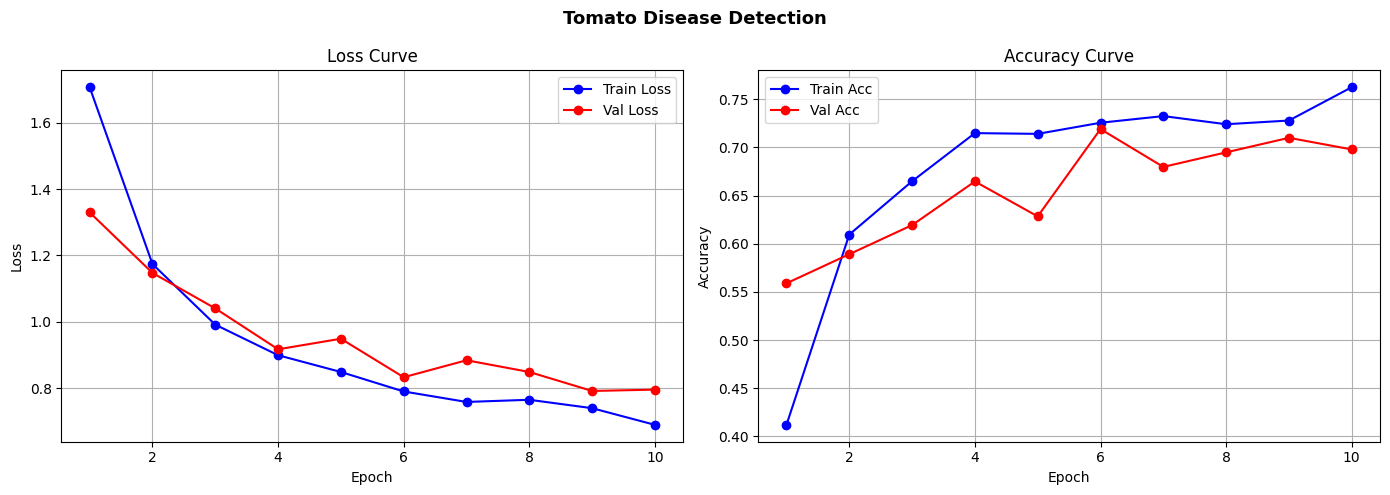

Saved: training_curves.png


In [20]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
    ax1.set_title('Loss Curve');  ax1.set_xlabel('Epoch');  ax1.set_ylabel('Loss')
    ax1.legend();  ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
    ax2.set_title('Accuracy Curve');  ax2.set_xlabel('Epoch');  ax2.set_ylabel('Accuracy')
    ax2.legend();  ax2.grid(True)

    plt.suptitle('Tomato Disease Detection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_BASE, 'training_curves.png'), dpi=150)
    plt.show()
    print('Saved: training_curves.png')

plot_history(history)

## ✅ Step 10: Evaluate Model (Accuracy + Classification Report + Confusion Matrix)

Overall Accuracy: 71.90%

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      0.41      0.58        22
                        Tomato___Early_blight       0.60      0.42      0.49        60
                         Tomato___Late_blight       0.81      0.74      0.77        23
                           Tomato___Leaf_Mold       0.61      0.86      0.71        81
                  Tomato___Septoria_leaf_spot       0.75      0.82      0.78        22
Tomato___Spider_mites Two-spotted_spider_mite       0.91      0.84      0.88        25
                         Tomato___Target_Spot       0.76      0.92      0.83        24
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.85      0.92        20
                 Tomato___Tomato_mosaic_virus       0.78      0.95      0.86        22
                             Tomato___healthy       0.75      0.56      0.64    

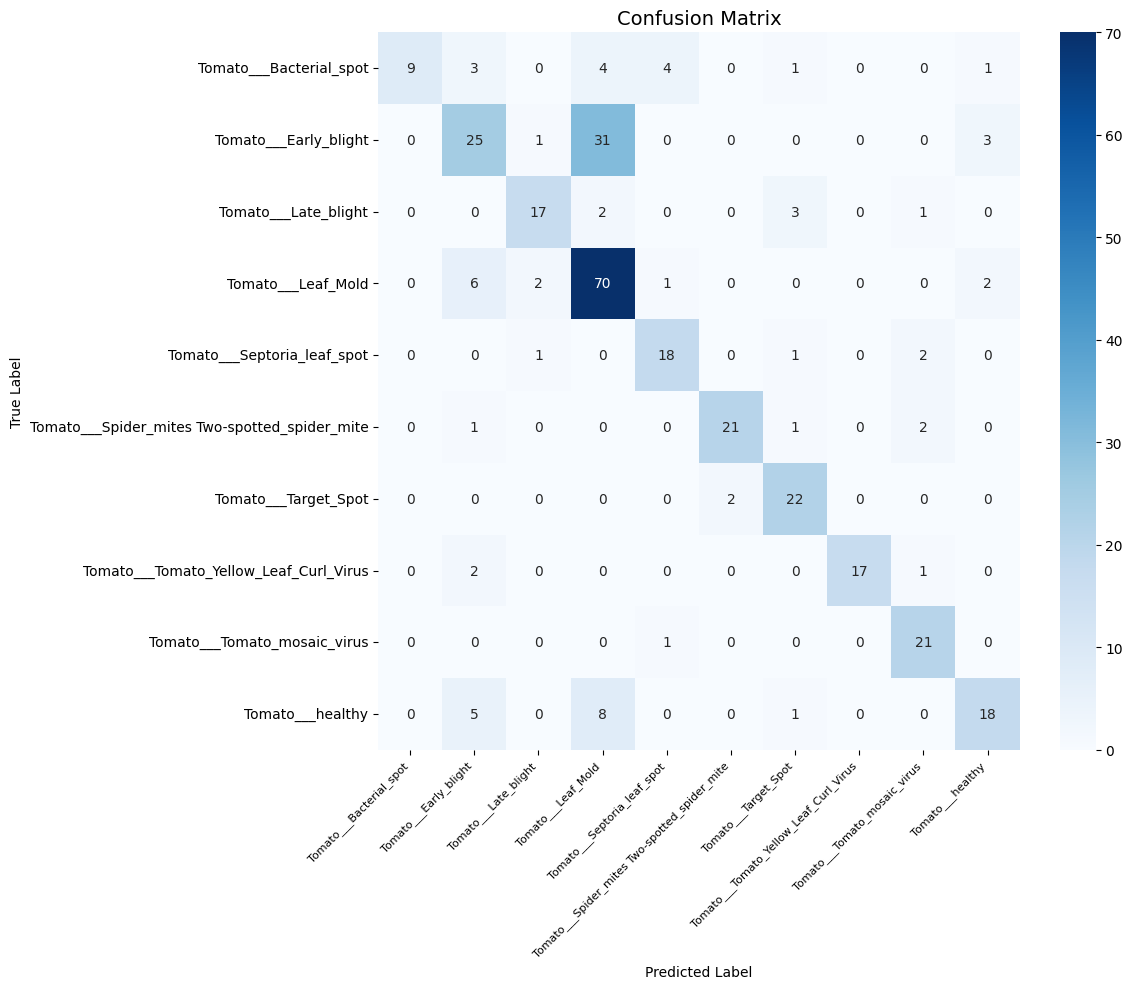

Saved: confusion_matrix.png


np.float64(0.7190332326283988)

In [18]:
def evaluate_model(model, dataloaders, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            outputs = model(inputs.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = np.mean(all_preds == all_labels)
    print(f'Overall Accuracy: {accuracy*100:.2f}%')

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14)
    plt.ylabel('True Label');  plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_BASE, 'confusion_matrix.png'), dpi=150)
    plt.show()
    print('Saved: confusion_matrix.png')
    return accuracy

evaluate_model(model, dataloaders, class_names)

## ✅ Step 11: Predict a Single Image

In [19]:
def predict_image(image_path, class_names, model_path=MODEL_SAVE):
    """
    Loads saved model and predicts disease class for one image.
    Returns: class name, confidence %
    """
    # Load model
    mdl = build_model(num_classes=len(class_names))
    mdl.load_state_dict(torch.load(model_path, map_location=device))
    mdl.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = mdl(tensor)
        probs   = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    class_name = class_names[pred_idx.item()]
    confidence = conf.item() * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'Predicted: {class_name}\nConfidence: {confidence:.2f}%', fontsize=11)
    plt.axis('off');  plt.tight_layout();  plt.show()

    print(f'Class     : {class_name}')
    print(f'Confidence: {confidence:.2f}%')
    return class_name, confidence

# ── HOW TO USE ──────────────────────────────────────────────────────────────
# Change the path below to any tomato leaf image in your Drive, then run:
#
# test_image = '/content/drive/MyDrive/tomato_project/dataset/val/Tomato___healthy/some_image.jpg'
# predict_image(test_image, class_names)
# ────────────────────────────────────────────────────────────────────────────
print('predict_image() is ready. Change test_image path above and run!')

predict_image() is ready. Change test_image path above and run!
